# Упражнение 8.1

Проверим, как параметры гауссова окна влияют на частотную характеристику фильтра.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal

from thinkdsp import SquareSignal, Wave, decorate

Возьмем квадратный сигнал и вспомогательную функцию для дополнения окна нулями.

In [3]:
signal = SquareSignal(freq=440)
wave = signal.make_wave(duration=1, framerate=44100)
spectrum = wave.make_spectrum()


def zero_pad(array, n):
    res = np.zeros(n)
    res[:len(array)] = array
    return res

Функция строит гауссово окно, сглаживает сигнал и сравнивает FFT окна с фактическим отношением амплитуд.

In [4]:
def gaussian_response(M=51, std=8):
    gaussian = scipy.signal.windows.gaussian(M=M, std=std)
    gaussian /= gaussian.sum()

    ys = np.convolve(wave.ys, gaussian, mode='same')
    smooth = Wave(ys, framerate=wave.framerate)
    spectrum2 = smooth.make_spectrum()

    ratio = spectrum2.amps / spectrum.amps
    ratio[spectrum.amps < 560] = 0

    padded = zero_pad(gaussian, len(wave))
    dft_gaussian = np.fft.rfft(padded)

    return gaussian, np.abs(dft_gaussian), ratio

Сначала посмотрим на обычный случай: длина окна достаточно велика относительно `std`.

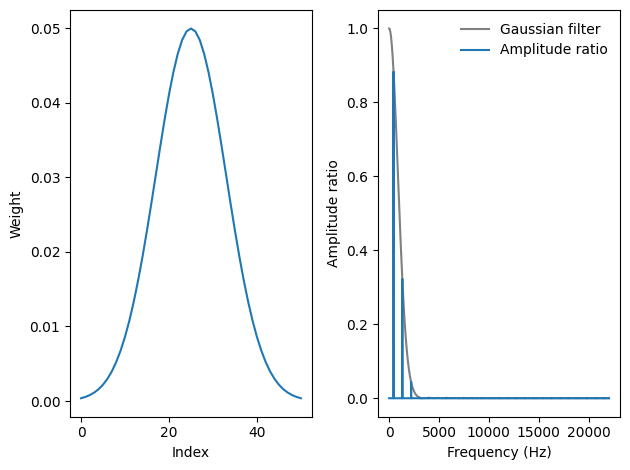

In [5]:
gaussian, dft_gaussian, ratio = gaussian_response(M=51, std=8)

plt.subplot(1, 2, 1)
plt.plot(gaussian)
decorate(xlabel='Index', ylabel='Weight')

plt.subplot(1, 2, 2)
plt.plot(dft_gaussian, color='gray', label='Gaussian filter')
plt.plot(ratio, label='Amplitude ratio')
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude ratio')

Теперь зафиксируем `M` и будем увеличивать `std`.

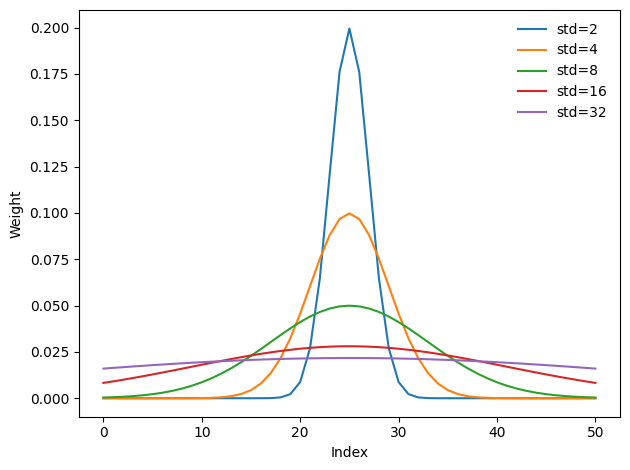

In [6]:
M = 51
stds = [2, 4, 8, 16, 32]

for std in stds:
    gaussian, dft_gaussian, ratio = gaussian_response(M=M, std=std)
    plt.plot(gaussian, label=f'std={std}')

decorate(xlabel='Index', ylabel='Weight')

При большом `std` окно перестает быть похожим на гауссиану и приближается к прямоугольному окну.

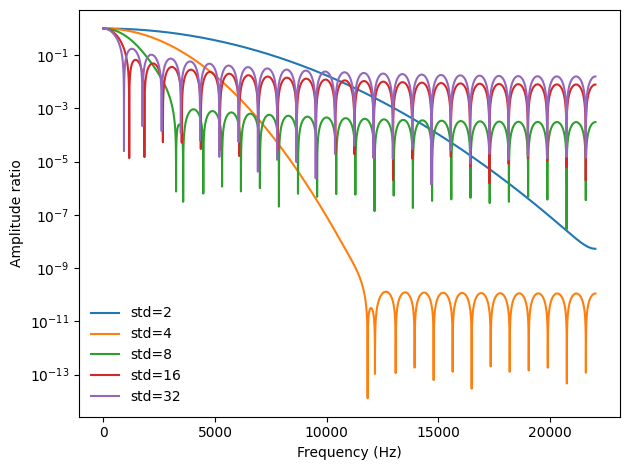

In [7]:
for std in stds:
    gaussian, dft_gaussian, ratio = gaussian_response(M=M, std=std)
    plt.plot(dft_gaussian, label=f'std={std}')

decorate(xlabel='Frequency (Hz)', ylabel='Amplitude ratio', yscale='log')

Оценим частоту среза как первую частоту, где амплитуда фильтра падает ниже 0.5.

In [8]:
def cutoff_frequency(response, threshold=0.5):
    below = np.where(response < threshold)[0]
    return below[0] if len(below) else None


cutoffs = []

for std in stds:
    gaussian, dft_gaussian, ratio = gaussian_response(M=M, std=std)
    cutoffs.append((std, cutoff_frequency(dft_gaussian)))

cutoffs

[(2, np.int64(4132)),
 (4, np.int64(2066)),
 (8, np.int64(1036)),
 (16, np.int64(635)),
 (32, np.int64(548))]

Вывод: если увеличивать `std`, но не увеличивать `M`, окно обрезается краями, становится почти прямоугольным, а частота среза перестает уменьшаться ожидаемым образом.